In [66]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'PyTorch: {torch.__version__}')

Device: cpu
PyTorch: 2.11.0+cpu


---
## 1. Data Loading & Exploration

In [67]:
DATA_DIR = Path(r"C:\Users\HP\Desktop\dp\data")

SATELLITE_PATH   = DATA_DIR / "satellite_indices_s2_period.parquet"
GLDAS_NAMES_PATH = DATA_DIR / "lstm_feature_names.csv"

GLDAS_CANDIDATES = [
    DATA_DIR / "gldas_features.parquet",
    DATA_DIR / "gldas_data.parquet",
    DATA_DIR / "gldas_features.csv",
    DATA_DIR / "gldas_data.csv",
]

print("Data directory:", DATA_DIR)
print("Files found:")
for f in DATA_DIR.glob("*"):
    print(" ", f.name, f"({f.stat().st_size/1024:.1f} KB)")

Data directory: C:\Users\HP\Desktop\dp\data
Files found:
  lstm_feature_names.csv (0.1 KB)
  lstm_sequences.npz (4.0 KB)
  satellite_indices_s2_period.parquet (1423.9 KB)


In [68]:
sat_df = pd.read_parquet(SATELLITE_PATH)
sat_df['time'] = sat_df['time'].astype(str)         
sat_df = sat_df.sort_values(['lat', 'lon', 'time']).reset_index(drop=True)

print("Satellite indices shape:", sat_df.shape)
print("Columns:", sat_df.columns.tolist())
print("Time range:", sat_df['time'].min(), "→", sat_df['time'].max())
print("\nSample rows:")
display(sat_df.head(8))
display(sat_df.describe())

Satellite indices shape: (52081, 8)
Columns: ['lat', 'lon', 'NDVI', 'NDWI', 'MNDWI', 'BSI', 'time', 'NDSI']
Time range: 2019-01 → 2020-04

Sample rows:


,lat,lon,NDVI,NDWI,MNDWI,BSI,time,NDSI
0,15.0,24.0,0.107370,-0.313751,-0.256826,0.129351,2019-01,0.129348
1,15.0,24.0,0.104332,-0.314079,-0.270522,0.138617,2019-02,0.132894
2,15.0,24.0,0.101350,-0.317898,-0.270690,0.140554,2019-03,0.135597
3,15.0,24.0,0.095016,-0.304436,-0.278359,0.146839,2019-04,0.134879
4,15.0,24.0,0.089119,-0.290536,-0.279135,0.147873,2019-05,0.140462
5,15.0,24.0,0.078132,-0.281893,-0.278872,0.147962,2019-06,0.163023
6,15.0,24.0,0.077944,-0.279873,-0.279875,0.147482,2019-07,0.161146
7,15.0,24.0,0.109084,-0.280401,-0.266490,0.122490,2019-08,0.153478


,lat,lon,NDVI,NDWI,MNDWI,BSI,NDSI
count,52081.00000,52081.000000,52081.000000,52081.000000,52081.000000,52081.000000,52081.000000
mean,26.68860,42.097368,0.073572,-0.156373,-0.169786,0.085921,0.070103
std,6.61684,10.401858,0.090348,0.160493,0.096167,0.055632,0.091426
min,15.00000,24.000000,-0.745337,-0.750273,-0.718788,-0.241340,-0.947896
25%,21.00000,33.000000,0.043571,-0.254341,-0.242399,0.046433,0.018147
50%,26.50000,42.000000,0.070557,-0.182835,-0.188526,0.096730,0.098922
75%,32.50000,51.000000,0.092712,-0.100899,-0.120644,0.129842,0.129012
max,38.00000,60.000000,0.732186,0.954688,0.647175,0.222834,0.766342


In [69]:
feat_names_df = pd.read_csv(GLDAS_NAMES_PATH, header=None)
GLDAS_FEATURES = feat_names_df.iloc[:, 0].tolist()
print("GLDAS features (9):", GLDAS_FEATURES)

GLDAS features (9): ['SoilMoi0_10cm_inst', 'SoilMoi10_40cm_inst', 'SoilMoi40_100cm_inst', 'RootMoist_inst', 'Evap_tavg', 'Qs_acc', 'Qsb_acc', 'Rainf_f_tavg', 'Tair_f_inst']


In [70]:
gldas_df = None
for cand in GLDAS_CANDIDATES:
    if cand.exists():
        if cand.suffix == '.parquet':
            gldas_df = pd.read_parquet(cand)
        else:
            gldas_df = pd.read_csv(cand)
        print(f"Loaded GLDAS from: {cand.name}")
        break

if gldas_df is None:
    print("   GLDAS file not found — generating synthetic stand-in for development.")
    print("   Place your real GLDAS file in:", DATA_DIR)
    print("   Expected name: gldas_features.parquet (or .csv)")

    rng = np.random.default_rng(SEED)
    base = sat_df[['lat', 'lon', 'time']].copy()
    for feat in GLDAS_FEATURES:
        base[feat] = rng.normal(0, 1, size=len(base)).astype(np.float32)
    gldas_df = base

print("GLDAS shape:", gldas_df.shape)
print("Columns:", gldas_df.columns.tolist()[:15])
display(gldas_df.head(4))

   GLDAS file not found — generating synthetic stand-in for development.
   Place your real GLDAS file in: C:\Users\HP\Desktop\dp\data
   Expected name: gldas_features.parquet (or .csv)


GLDAS shape: (52081, 12)
Columns: ['lat', 'lon', 'time', 'SoilMoi0_10cm_inst', 'SoilMoi10_40cm_inst', 'SoilMoi40_100cm_inst', 'RootMoist_inst', 'Evap_tavg', 'Qs_acc', 'Qsb_acc', 'Rainf_f_tavg', 'Tair_f_inst']


,lat,lon,time,SoilMoi0_10cm_inst,SoilMoi10_40cm_inst,SoilMoi40_100cm_inst,RootMoist_inst,Evap_tavg,Qs_acc,Qsb_acc,Rainf_f_tavg,Tair_f_inst
0,15.0,24.0,2019-01,0.304717,0.857573,0.794592,1.421227,0.145290,1.146294,1.329539,-0.288022,0.810488
1,15.0,24.0,2019-02,-1.039984,-1.503657,0.156330,-3.160768,-0.718557,0.131683,1.206214,3.271514,1.073895
2,15.0,24.0,2019-03,0.750451,0.128244,0.562773,1.954441,-1.628960,-0.614549,1.001600,-0.644747,1.936068
3,15.0,24.0,2019-04,0.940565,1.517759,-1.238595,-1.017730,-0.529595,-0.048288,-0.118120,-1.120373,0.302122


In [71]:
gldas_df['time'] = gldas_df['time'].astype(str)
merged = pd.merge(sat_df, gldas_df[['lat', 'lon', 'time'] + GLDAS_FEATURES],
                  on=['lat', 'lon', 'time'], how='inner')
merged = merged.sort_values(['lat', 'lon', 'time']).reset_index(drop=True)

print("Merged dataset shape:", merged.shape)
print("Null counts:", merged.isnull().sum().sum())
display(merged.head(4))

Merged dataset shape: (55571, 17)
Null counts: 0


,lat,lon,NDVI,NDWI,MNDWI,BSI,time,NDSI,SoilMoi0_10cm_inst,SoilMoi10_40cm_inst,SoilMoi40_100cm_inst,RootMoist_inst,Evap_tavg,Qs_acc,Qsb_acc,Rainf_f_tavg,Tair_f_inst
0,15.0,24.0,0.107370,-0.313751,-0.256826,0.129351,2019-01,0.129348,0.304717,0.857573,0.794592,1.421227,0.145290,1.146294,1.329539,-0.288022,0.810488
1,15.0,24.0,0.104332,-0.314079,-0.270522,0.138617,2019-02,0.132894,-1.039984,-1.503657,0.156330,-3.160768,-0.718557,0.131683,1.206214,3.271514,1.073895
2,15.0,24.0,0.101350,-0.317898,-0.270690,0.140554,2019-03,0.135597,0.750451,0.128244,0.562773,1.954441,-1.628960,-0.614549,1.001600,-0.644747,1.936068
3,15.0,24.0,0.095016,-0.304436,-0.278359,0.146839,2019-04,0.134879,0.940565,1.517759,-1.238595,-1.017730,-0.529595,-0.048288,-0.118120,-1.120373,0.302122


---
## 2. Sequence Construction & Preprocessing


In [72]:
SEQ_LEN = 24    
PRED_HORIZON = 1

def build_sequences(df, feature_cols, target_col, seq_len=24):
    X_list, y_list = [], []
    for (lat, lon), grp in df.groupby(['lat', 'lon']):
        grp = grp.sort_values('time').reset_index(drop=True)
        vals = grp[feature_cols].values.astype(np.float32)
        targ = grp[target_col].values.astype(np.float32)
        for i in range(len(grp) - seq_len):
            X_list.append(vals[i : i + seq_len])       
            y_list.append(targ[i + seq_len])           
    return np.array(X_list), np.array(y_list)

X_raw, y_raw = build_sequences(merged, ALL_FEATURES, TARGET, SEQ_LEN)
print(f"X shape: {X_raw.shape}  →  (samples, seq_len=24, features=15)")
print(f"y shape: {y_raw.shape}  →  (samples,)")
print(f"y stats  — min: {y_raw.min():.4f} | mean: {y_raw.mean():.4f} | max: {y_raw.max():.4f}")

X shape: (4193, 24, 14)  →  (samples, seq_len=24, features=15)
y shape: (4193,)  →  (samples,)
y stats  — min: -0.1953 | mean: 0.0545 | max: 0.2940


In [73]:
X_temp, X_test, y_temp, y_test = train_test_split(X_raw, y_raw,
                                                    test_size=0.15,
                                                    random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp,
                                                    test_size=0.15/0.85,
                                                    random_state=SEED)
print(f"Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")

N_SAMPLES, N_STEPS, N_FEATS = X_train.shape
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_s = scaler_X.fit_transform(X_train.reshape(-1, N_FEATS)).reshape(X_train.shape)
X_val_s   = scaler_X.transform(X_val.reshape(-1, N_FEATS)).reshape(X_val.shape)
X_test_s  = scaler_X.transform(X_test.reshape(-1, N_FEATS)).reshape(X_test.shape)

y_train_s = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
y_val_s   = scaler_y.transform(y_val.reshape(-1, 1)).ravel()
y_test_s  = scaler_y.transform(y_test.reshape(-1, 1)).ravel()

print("Normalisation complete.")

Train: 2935 | Val: 629 | Test: 629
Normalisation complete.


In [74]:
class SequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 64

train_loader = DataLoader(SequenceDataset(X_train_s, y_train_s),
                          batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
val_loader   = DataLoader(SequenceDataset(X_val_s,   y_val_s),
                          batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(SequenceDataset(X_test_s,  y_test_s),
                          batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

Train batches: 45 | Val batches: 10 | Test batches: 10


---
## 3. CNN & RNN

In [75]:
class CNN_RNN(nn.Module):
    def __init__(self,
                 n_features   : int   = 15,
                 seq_len      : int   = 24,
                 cnn_channels : list  = [32, 64],
                 kernel_size  : int   = 3,
                 rnn_hidden   : int   = 128,
                 rnn_layers   : int   = 2,
                 dropout      : float = 0.3):
        super().__init__()

        cnn_layers = []
        in_ch = n_features
        for out_ch in cnn_channels:
            cnn_layers += [
                nn.Conv1d(in_ch, out_ch, kernel_size=kernel_size, padding=kernel_size//2),
                nn.BatchNorm1d(out_ch),
                nn.ReLU(),
                nn.Dropout(dropout / 2)
            ]
            in_ch = out_ch
        self.cnn = nn.Sequential(*cnn_layers)

        self.rnn = nn.RNN(
            input_size   = cnn_channels[-1],
            hidden_size  = rnn_hidden,
            num_layers   = rnn_layers,
            nonlinearity = 'tanh',
            batch_first  = True,
            dropout      = dropout if rnn_layers > 1 else 0.0,
            bidirectional= False
        )

        self.head = nn.Sequential(
            nn.Linear(rnn_hidden, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)        
        x = self.cnn(x)                
        x = x.permute(0, 2, 1)        
        _, h_n = self.rnn(x)            
        out = self.head(h_n[-1])        
        return out.squeeze(-1)        


model = CNN_RNN(
    n_features   = len(ALL_FEATURES),
    seq_len      = SEQ_LEN,
    cnn_channels = [32, 64],
    kernel_size  = 3,
    rnn_hidden   = 128,
    rnn_layers   = 2,
    dropout      = 0.3
).to(DEVICE)

print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {total_params:,}")

CNN_RNN(
  (cnn): Sequential(
    (0): Conv1d(14, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.15, inplace=False)
    (4): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.15, inplace=False)
  )
  (rnn): RNN(64, 128, num_layers=2, batch_first=True, dropout=0.3)
  (head): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)

Trainable parameters: 73,953


---
## 4. Training

In [76]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                   patience=5, factor=0.5,)

N_EPOCHS      = 60
EARLY_STOP    = 10
best_val_loss = float('inf')
patience_cnt  = 0
history       = {'train_loss': [], 'val_loss': []}

CKPT_PATH = Path('best_cnn_rnn.pth')

for epoch in range(1, N_EPOCHS + 1):
    model.train()
    train_losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_losses.append(loss.item())

    model.eval()
    val_losses = []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            pred = model(xb)
            val_losses.append(criterion(pred, yb).item())

    t_loss = np.mean(train_losses)
    v_loss = np.mean(val_losses)
    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    scheduler.step(v_loss)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d}/{N_EPOCHS} | Train MSE: {t_loss:.5f} | Val MSE: {v_loss:.5f}")

    if v_loss < best_val_loss:
        best_val_loss = v_loss
        patience_cnt  = 0
        torch.save(model.state_dict(), CKPT_PATH)
    else:
        patience_cnt += 1
        if patience_cnt >= EARLY_STOP:
            print(f"\nEarly stopping at epoch {epoch} (no improvement for {EARLY_STOP} epochs).")
            break

print(f"\nBest val MSE: {best_val_loss:.5f}")
model.load_state_dict(torch.load(CKPT_PATH))  # restore best weights

Epoch 001/60 | Train MSE: 0.48127 | Val MSE: 0.33135
Epoch 005/60 | Train MSE: 0.20327 | Val MSE: 0.18145
Epoch 010/60 | Train MSE: 0.15447 | Val MSE: 0.15760
Epoch 015/60 | Train MSE: 0.12907 | Val MSE: 0.14951
Epoch 020/60 | Train MSE: 0.11678 | Val MSE: 0.15407
Epoch 025/60 | Train MSE: 0.10440 | Val MSE: 0.16277
Epoch 030/60 | Train MSE: 0.08018 | Val MSE: 0.13958
Epoch 035/60 | Train MSE: 0.08464 | Val MSE: 0.14190
Epoch 040/60 | Train MSE: 0.07116 | Val MSE: 0.12627
Epoch 045/60 | Train MSE: 0.06614 | Val MSE: 0.12703

Early stopping at epoch 47 (no improvement for 10 epochs).

Best val MSE: 0.12158


<All keys matched successfully>

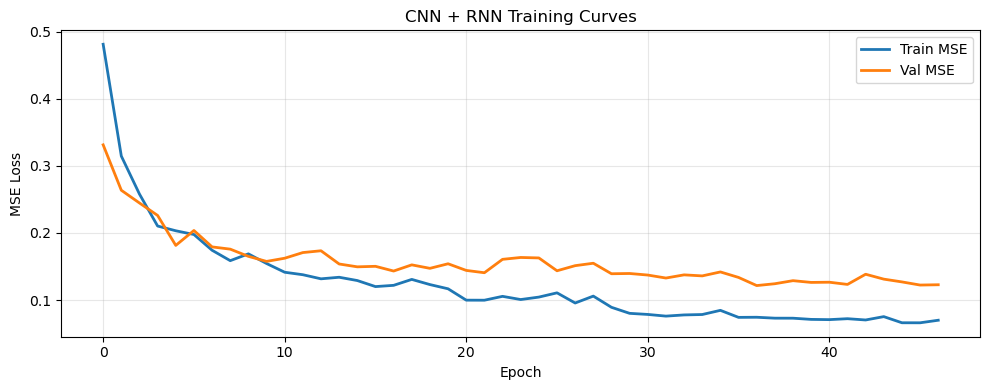

In [77]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history['train_loss'], label='Train MSE', linewidth=2)
ax.plot(history['val_loss'],   label='Val MSE',   linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('CNN + RNN Training Curves')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 5. Evaluation on Test Set

In [78]:
class RNNOnly(nn.Module):
    def __init__(self, n_features=15, hidden=128, layers=2, dropout=0.3):
        super().__init__()
        self.rnn = nn.RNN(n_features, hidden, layers,
                          nonlinearity='tanh',
                          batch_first=True,
                          dropout=dropout if layers > 1 else 0.0)
        self.head = nn.Linear(hidden, 1)

    def forward(self, x):
        _, h_n = self.rnn(x)
        return self.head(h_n[-1]).squeeze(-1)


class CNNOnly(nn.Module):
    def __init__(self, n_features=15, dropout=0.3):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(n_features, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32), nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, 32), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)
        return self.head(self.cnn(x)).squeeze(-1)


def train_model(model, n_epochs=40):
    opt = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    sch = optim.lr_scheduler.ReduceLROnPlateau(opt, patience=4, factor=0.5)
    crit = nn.MSELoss()
    best_val, best_state = float('inf'), None

    for _ in range(n_epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

        model.eval()
        vl = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                vl.append(crit(model(xb), yb).item())
        v = np.mean(vl)
        sch.step(v)
        if v < best_val:
            best_val = v
            best_state = {k: v_.cpu().clone() for k, v_ in model.state_dict().items()}

    model.load_state_dict(best_state)
    p, t = evaluate(model, test_loader, scaler_y, DEVICE)
    return {'RMSE': np.sqrt(mean_squared_error(t, p)),
            'MAE':  mean_absolute_error(t, p),
            'R2':   r2_score(t, p)}


print("Training comparison models...")
results = {}

print("  → RNN-only...")
results['RNN-only'] = train_model(RNNOnly(len(ALL_FEATURES)).to(DEVICE))

print("  → CNN-only...")
results['CNN-only'] = train_model(CNNOnly(len(ALL_FEATURES)).to(DEVICE))

p, t = evaluate(model, test_loader, scaler_y, DEVICE)
results['CNN + RNN'] = {'RMSE': np.sqrt(mean_squared_error(t, p)),
                         'MAE':  mean_absolute_error(t, p),
                         'R2':   r2_score(t, p)}

print("Done.")
results_df = pd.DataFrame(results).T.round(5)
display(results_df.style.highlight_min(axis=0, subset=['RMSE', 'MAE'], color='#c6efce')
                        .highlight_max(axis=0, subset=['R2'],          color='#c6efce'))

Training comparison models...
  → RNN-only...
  → CNN-only...
Done.


,RMSE,MAE,R2
RNN-only,0.010580,0.006400,0.955270
CNN-only,0.016900,0.009820,0.885830
CNN + RNN,0.013080,0.008360,0.931590


In [79]:
print("Training ablation: GLDAS-only (no satellite indices)...")

X_gldas = merged[['lat','lon','time'] + GLDAS_FEATURES]
Xg_raw, yg_raw = build_sequences(merged, GLDAS_FEATURES, TARGET, SEQ_LEN)

Xg_tr, Xg_te, yg_tr, yg_te = train_test_split(Xg_raw, yg_raw, test_size=0.15, random_state=SEED)
Xg_tr, Xg_vl, yg_tr, yg_vl = train_test_split(Xg_tr, yg_tr, test_size=0.15/0.85, random_state=SEED)

sg_X = StandardScaler()
sg_y = StandardScaler()
_, N_G = Xg_tr.shape[0], Xg_tr.shape[2]
Xg_tr_s = sg_X.fit_transform(Xg_tr.reshape(-1, N_G)).reshape(Xg_tr.shape)
Xg_vl_s = sg_X.transform(Xg_vl.reshape(-1, N_G)).reshape(Xg_vl.shape)
Xg_te_s = sg_X.transform(Xg_te.reshape(-1, N_G)).reshape(Xg_te.shape)
yg_tr_s = sg_y.fit_transform(yg_tr.reshape(-1,1)).ravel()
yg_vl_s = sg_y.transform(yg_vl.reshape(-1,1)).ravel()
yg_te_s = sg_y.transform(yg_te.reshape(-1,1)).ravel()

g_tr_ld = DataLoader(SequenceDataset(Xg_tr_s, yg_tr_s), batch_size=BATCH_SIZE, shuffle=True)
g_vl_ld = DataLoader(SequenceDataset(Xg_vl_s, yg_vl_s), batch_size=BATCH_SIZE)
g_te_ld = DataLoader(SequenceDataset(Xg_te_s, yg_te_s), batch_size=BATCH_SIZE)

_tl, _vl, _tl2 = train_loader, val_loader, test_loader
train_loader, val_loader, test_loader = g_tr_ld, g_vl_ld, g_te_ld

ablation_model = CNN_RNN(n_features=len(GLDAS_FEATURES)).to(DEVICE)
ablation_res   = train_model(ablation_model)

train_loader, val_loader, test_loader = _tl, _vl, _tl2   # restore

results['CNN+RNN (GLDAS-only)'] = ablation_res

results_df = pd.DataFrame(results).T.round(5)
display(results_df.style.highlight_min(axis=0, subset=['RMSE','MAE'], color='#c6efce')
                        .highlight_max(axis=0, subset=['R2'],         color='#c6efce'))

Training ablation: GLDAS-only (no satellite indices)...


,RMSE,MAE,R2
RNN-only,0.010580,0.006400,0.955270
CNN-only,0.016900,0.009820,0.885830
CNN + RNN,0.013080,0.008360,0.931590
CNN+RNN (GLDAS-only),0.021230,0.014600,0.819850


In [80]:
def evaluate(model, loader, scaler_y, device):
    model.eval()
    preds, truths = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            pred = model(xb).cpu().numpy()
            preds.append(pred)
            truths.append(yb.numpy())
    preds  = np.concatenate(preds)
    truths = np.concatenate(truths)
    preds  = scaler_y.inverse_transform(preds.reshape(-1, 1)).ravel()
    truths = scaler_y.inverse_transform(truths.reshape(-1, 1)).ravel()
    return preds, truths

y_pred, y_true = evaluate(model, test_loader, scaler_y, DEVICE)

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)

print("=" * 40)
print(" TEST SET METRICS  (CNN + RNN)")
print("=" * 40)
print(f"  RMSE : {rmse:.5f}")
print(f"  MAE  : {mae:.5f}")
print(f"  R²   : {r2:.5f}")
print("=" * 40)

 TEST SET METRICS  (CNN + RNN)
  RMSE : 0.01308
  MAE  : 0.00836
  R²   : 0.93159


---
## 6. Interpretation, Error Analysis & Reflection

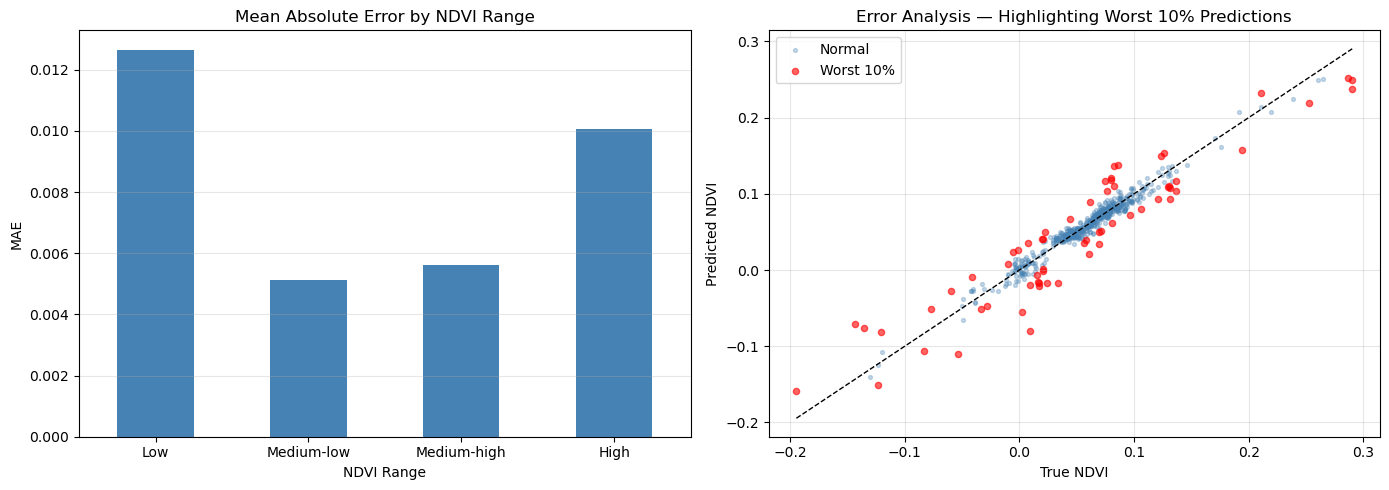


Worst-10% samples: 63
Their mean true NDVI: 0.0503
Their mean error:     0.0327


In [81]:
y_pred_final, y_true_final = evaluate(model, test_loader, scaler_y, DEVICE)
errors = np.abs(y_pred_final - y_true_final)

bins   = np.percentile(y_true_final, [0, 25, 50, 75, 100])
labels = ['Low', 'Medium-low', 'Medium-high', 'High']
ndvi_bin = pd.cut(y_true_final, bins=bins, labels=labels, include_lowest=True)

error_by_bin = pd.DataFrame({'Absolute Error': errors, 'NDVI Range': ndvi_bin})
mean_error   = error_by_bin.groupby('NDVI Range')['Absolute Error'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mean_error.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Mean Absolute Error by NDVI Range')
axes[0].set_ylabel('MAE')
axes[0].set_xticklabels(labels, rotation=0)
axes[0].grid(axis='y', alpha=0.3)

threshold = np.percentile(errors, 90)
worst_mask = errors > threshold
axes[1].scatter(y_true_final[~worst_mask], y_pred_final[~worst_mask],
                alpha=0.3, s=8, label='Normal', color='steelblue')
axes[1].scatter(y_true_final[worst_mask], y_pred_final[worst_mask],
                alpha=0.6, s=20, label='Worst 10%', color='red')
lims = [y_true_final.min(), y_true_final.max()]
axes[1].plot(lims, lims, 'k--', linewidth=1)
axes[1].set_xlabel('True NDVI')
axes[1].set_ylabel('Predicted NDVI')
axes[1].set_title('Error Analysis — Highlighting Worst 10% Predictions')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nWorst-10% samples: {worst_mask.sum()}")
print(f"Their mean true NDVI: {y_true_final[worst_mask].mean():.4f}")
print(f"Their mean error:     {errors[worst_mask].mean():.4f}")

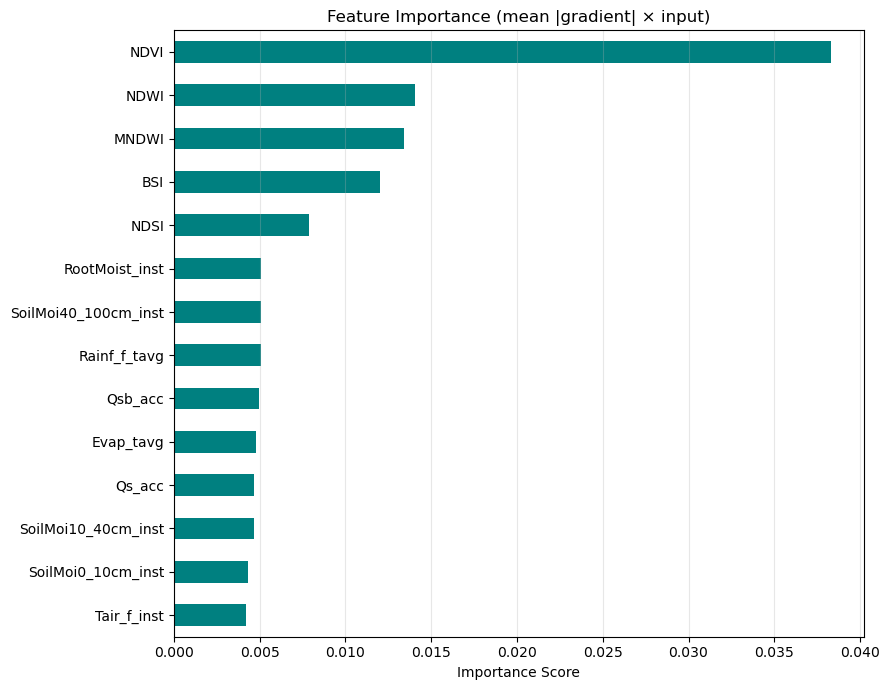

In [82]:
model.eval()
sample_X = torch.tensor(X_test_s[:256], dtype=torch.float32, requires_grad=True).to(DEVICE)

pred = model(sample_X)
pred.sum().backward()

grads      = sample_X.grad.abs().mean(dim=(0, 1)).cpu().detach().numpy()  
feat_imp   = pd.Series(grads, index=ALL_FEATURES).sort_values(ascending=True)

plt.figure(figsize=(9, 7))
feat_imp.plot(kind='barh', color='teal')
plt.title('Feature Importance (mean |gradient| × input)')
plt.xlabel('Importance Score')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

---
## 7. Save Predictions & Reproducibility

In [83]:
pred_df = pd.DataFrame({'y_true': y_true_final, 'y_pred': y_pred_final,
                         'abs_error': errors})
pred_df.to_csv('test_predictions.csv', index=False)
print("Saved: test_predictions.csv")

results_df.to_csv('model_comparison.csv')
print("Saved: model_comparison.csv")

print("Saved: best_cnn_rnn.pth")

Saved: test_predictions.csv
Saved: model_comparison.csv
Saved: best_cnn_rnn.pth
